In [1249]:


from sklearn.compose import ColumnTransformer

from pathlib import Path
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import xgboost


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)
import joblib

In [1250]:
dataset_path = Path("../data/ames_dataset.csv")
df = pd.read_csv(dataset_path)
df.drop(columns=["Id"], inplace=True)
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,...,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,...,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,...,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,...,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,...,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [1251]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


In [1252]:
df["GarageType"].unique()

<StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str

In [1253]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

# How many numeric vs categorical columns?

In [1254]:
print('Column type breakdown:')
print(df.dtypes.value_counts())
print(f'\nNumeric columns : {df.select_dtypes(include="number").shape[1]}')
print(f'Categorical cols: {df.select_dtypes(include="object").shape[1]}')

Column type breakdown:
str        43
int64      34
float64     3
Name: count, dtype: int64

Numeric columns : 37
Categorical cols: 43


C:\Users\pro\AppData\Local\Temp\ipykernel_14600\4224453793.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f'Categorical cols: {df.select_dtypes(include="object").shape[1]}')


# Null summary on training set only

In [1255]:

null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(1)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_pct':   null_pct,
    'dtype':      df.dtypes
}).query('null_count > 0').sort_values('null_pct', ascending=False)

print(f'Columns with missing values: {len(null_summary)}')
null_summary

Columns with missing values: 19


,null_count,null_pct,dtype
PoolQC,1453,99.5,str
MiscFeature,1406,96.3,str
Alley,1369,93.8,str
Fence,1179,80.8,str
MasVnrType,872,59.7,str
FireplaceQu,690,47.3,str
LotFrontage,259,17.7,float64
GarageType,81,5.5,str
GarageYrBlt,81,5.5,float64
GarageFinish,81,5.5,str


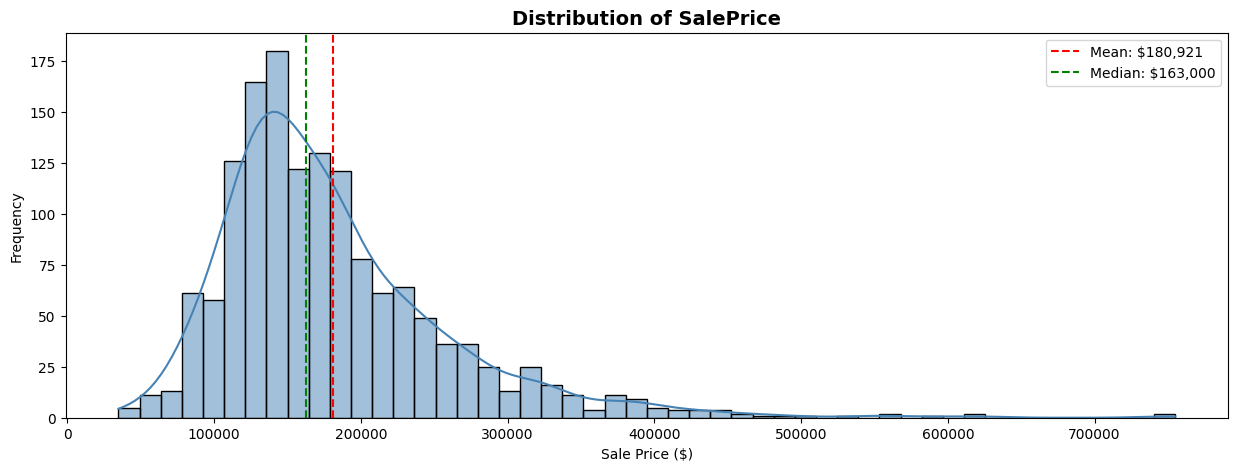

In [1256]:
# 📈 Visualize SalePrice distribution
plt.figure(1, figsize=(15, 5))

# Histogram with KDE
sns.histplot(df['SalePrice'], kde=True, color='steelblue', bins=50)
plt.title('Distribution of SalePrice', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price ($)')
plt.ylabel('Frequency')
plt.axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["SalePrice"].mean():,.0f}')
plt.axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Median: ${df["SalePrice"].median():,.0f}')
plt.legend()



plt.show()

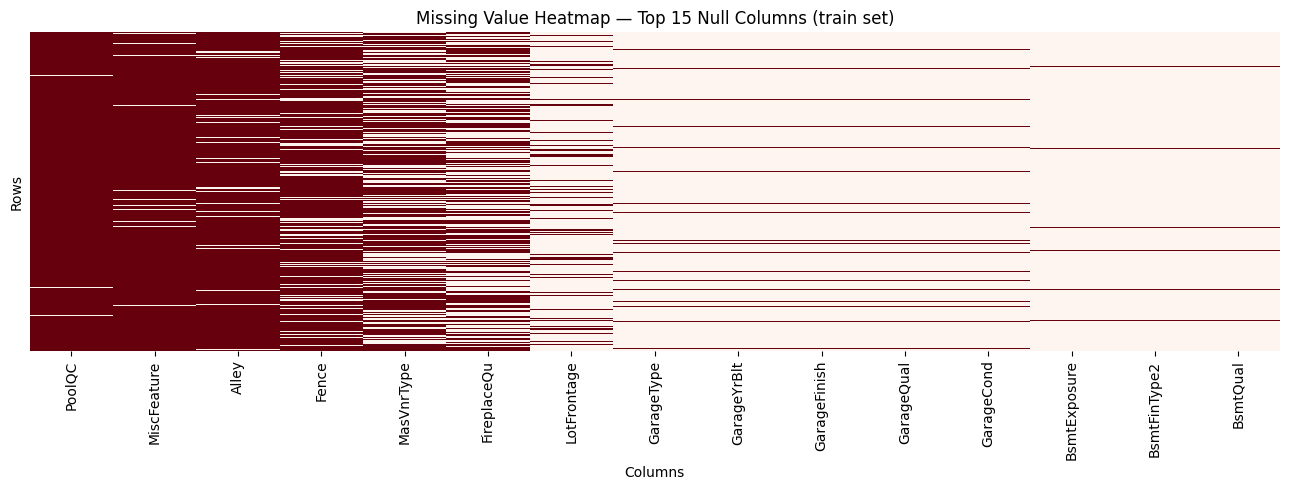

In [1257]:
top_null_cols = null_summary.head(15).index.tolist()

plt.figure(figsize=(13, 5))
sns.heatmap(df[top_null_cols].isnull(), cbar=False, yticklabels=False,
            cmap='Reds')
plt.title('Missing Value Heatmap — Top 15 Null Columns (train set)')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

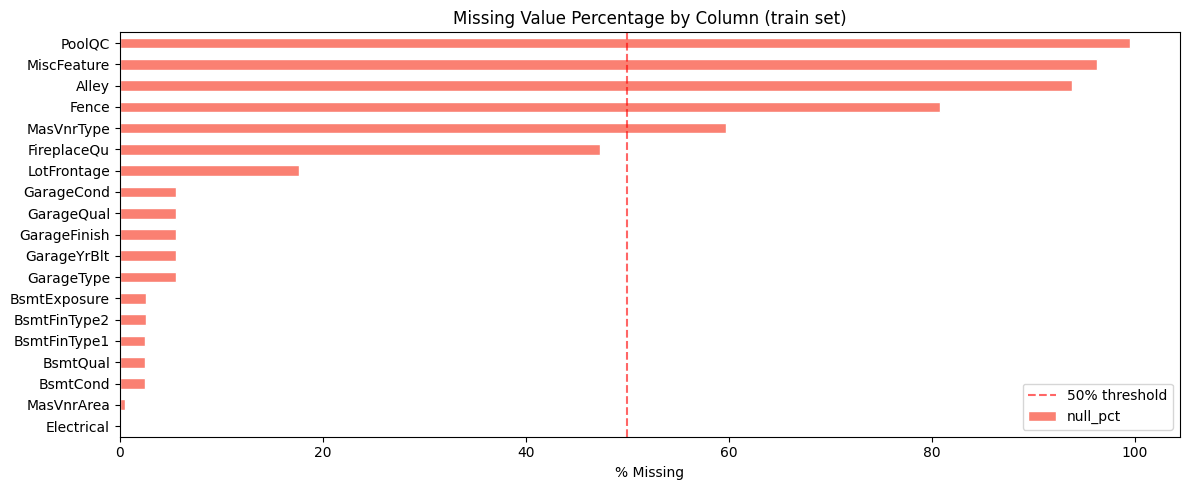

In [1258]:
# Bar chart of null percentages
plt.figure(figsize=(12, 5))
null_summary['null_pct'].sort_values(ascending=True).plot(
    kind='barh', color='salmon', edgecolor='white'
)
plt.axvline(50, color='red', linestyle='--', alpha=0.6, label='50% threshold')
plt.title('Missing Value Percentage by Column (train set)')
plt.xlabel('% Missing')
plt.legend()
plt.tight_layout()
plt.show()

In [1259]:
# Garage-related columns — are they null on the same rows?
garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'GarageYrBlt', 'GarageArea', 'GarageCars']
garage_null = df[garage_cols].isnull()

print('Garage null overlap (number of rows where each pair is BOTH null):')
overlap = garage_null.T.dot(garage_null)
print(overlap)
print(f'\nRows with any garage null: {garage_null.any(axis=1).sum()}')
print(f'Rows with all garage cols null: {garage_null.all(axis=1).sum()}')
print('\nConclusion: garage nulls are co-occurring -> these houses have no garage.')

Garage null overlap (number of rows where each pair is BOTH null):
              GarageType  GarageFinish  GarageQual  GarageCond  GarageYrBlt  \
GarageType          True          True        True        True         True   
GarageFinish        True          True        True        True         True   
GarageQual          True          True        True        True         True   
GarageCond          True          True        True        True         True   
GarageYrBlt         True          True        True        True         True   
GarageArea         False         False       False       False        False   
GarageCars         False         False       False       False        False   

              GarageArea  GarageCars  
GarageType         False       False  
GarageFinish       False       False  
GarageQual         False       False  
GarageCond         False       False  
GarageYrBlt        False       False  
GarageArea         False       False  
GarageCars         False   

In [1260]:
# Basement-related columns — same pattern?
bsmt_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
bsmt_null = df[bsmt_cols].isnull()

print('Basement null co-occurrence:')
print(f'Rows where ALL basement quality cols are null: {bsmt_null[["BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2"]].all(axis=1).sum()}')
print(f'Rows where any basement area col is null:      {bsmt_null[["BsmtFinSF1","TotalBsmtSF"]].any(axis=1).sum()}')
print('\nConclusion: categorical bsmt cols null = no basement -> fill with None / 0.')

Basement null co-occurrence:
Rows where ALL basement quality cols are null: 37
Rows where any basement area col is null:      0

Conclusion: categorical bsmt cols null = no basement -> fill with None / 0.


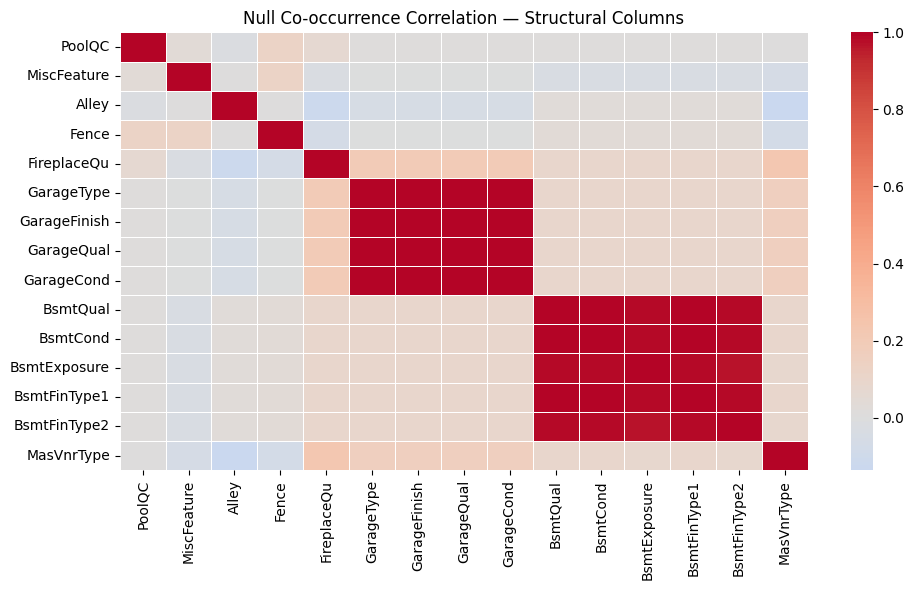

High correlation = these columns are null on the same rows = same underlying missing feature.


In [1261]:
# Heatmap of all structural null co-occurrences (rows where multiple features are null together)
structural_indicator_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]
present_structural = [c for c in structural_indicator_cols if c in df.columns]
null_indicator = df[present_structural].isnull().astype(int)

plt.figure(figsize=(10, 6))
sns.heatmap(null_indicator.corr(), annot=False, cmap='coolwarm', center=0,
            linewidths=0.5)
plt.title('Null Co-occurrence Correlation — Structural Columns')
plt.tight_layout()
plt.show()

print('High correlation = these columns are null on the same rows = same underlying missing feature.')

In [1262]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Number of numerical features: {len(numerical_features)}")
print(f"\nNumerical features: {numerical_features}")

Number of numerical features: 37

Numerical features: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']


In [1263]:
# Categorical nulls that mean 'not present' -> fill with 'None'
categorical_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence',
    'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType'
]

# Numeric nulls that mean 'not present' -> fill with 0
numeric_zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

# Genuinely unknown numeric -> fill with median (fit on train)
numeric_median_cols = ['LotFrontage']

# Genuinely unknown categorical -> fill with mode (fit on train)
categorical_mode_cols = [
    'Electrical', 'MSZoning', 'Utilities', 'Functional',
    'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType'
]

# Verify all null columns are accounted for
all_handled = (categorical_none_cols + numeric_zero_cols +
               numeric_median_cols + categorical_mode_cols)
unhandled = [c for c in null_summary.index if c not in all_handled]
print(f'Unhandled null columns: {unhandled if unhandled else "None — all covered"}')

Unhandled null columns: None — all covered


In [1264]:
# Strategy summary table
strategy_rows = []
for col in categorical_none_cols:
    strategy_rows.append({'column': col, 'strategy': "fill 'None'", 'reason': 'structural — feature absent'})
for col in numeric_zero_cols:
    strategy_rows.append({'column': col, 'strategy': 'fill 0', 'reason': 'structural — area/count is 0'})
for col in numeric_median_cols:
    strategy_rows.append({'column': col, 'strategy': 'median (train)', 'reason': 'unknown — measurement gap'})
for col in categorical_mode_cols:
    strategy_rows.append({'column': col, 'strategy': 'mode (train)', 'reason': 'unknown — recording gap'})

strategy_df = pd.DataFrame(strategy_rows)
print('Imputation decision log:')
strategy_df

Imputation decision log:


,column,strategy,reason
0,PoolQC,fill 'None',structural — feature absent
1,MiscFeature,fill 'None',structural — feature absent
2,Alley,fill 'None',structural — feature absent
3,Fence,fill 'None',structural — feature absent
4,FireplaceQu,fill 'None',structural — feature absent
5,GarageType,fill 'None',structural — feature absent
6,GarageFinish,fill 'None',structural — feature absent
7,GarageQual,fill 'None',structural — feature absent
8,GarageCond,fill 'None',structural — feature absent
9,BsmtQual,fill 'None',structural — feature absent


In [1265]:
# 🔍 Analyze missing values
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data = missing_data[missing_data > 0]
missing_percent = (missing_data / len(df)) * 100

print(f"Features with missing values: {len(missing_data)}")
print(f"\nTop 10 features by missing count:")
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing %': missing_percent.round(2)
})
print(missing_df.head(10))

Features with missing values: 19

Top 10 features by missing count:
              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageQual               81       5.55
GarageType               81       5.55
GarageFinish             81       5.55


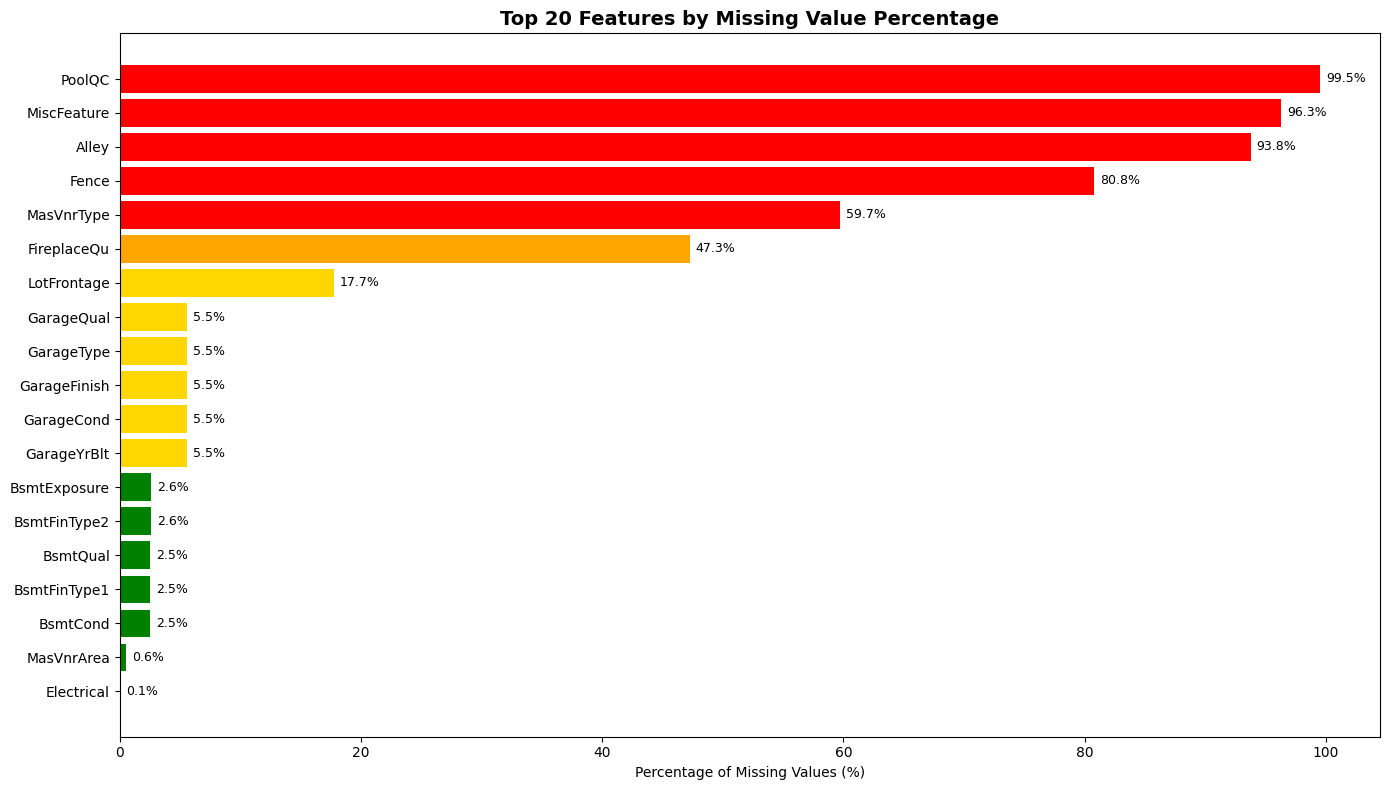


🎨 Color Legend:
🟢 Green: < 5% missing (minimal)
🟡 Gold: 5-20% missing (moderate)
🟠 Orange: 20-50% missing (significant)
🔴 Red: > 50% missing (severe)


In [1266]:
# 📊 Visualize missing value patterns
plt.figure(figsize=(14, 8))
missing_df_top20 = missing_df.head(20)

colors = ['red' if x > 50 else 'orange' if x > 20 else 'gold' if x > 5 else 'green' for x in missing_df_top20['Missing %']]
bars = plt.barh(range(len(missing_df_top20)), missing_df_top20['Missing %'], color=colors)
plt.yticks(range(len(missing_df_top20)), missing_df_top20.index)
plt.xlabel('Percentage of Missing Values (%)')
plt.title('Top 20 Features by Missing Value Percentage', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add percentage labels
for i, (idx, row) in enumerate(missing_df_top20.iterrows()):
    plt.text(row['Missing %'] + 0.5, i, f'{row["Missing %"]:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n🎨 Color Legend:")
print("🟢 Green: < 5% missing (minimal)")
print("🟡 Gold: 5-20% missing (moderate)")
print("🟠 Orange: 20-50% missing (significant)")
print("🔴 Red: > 50% missing (severe)")

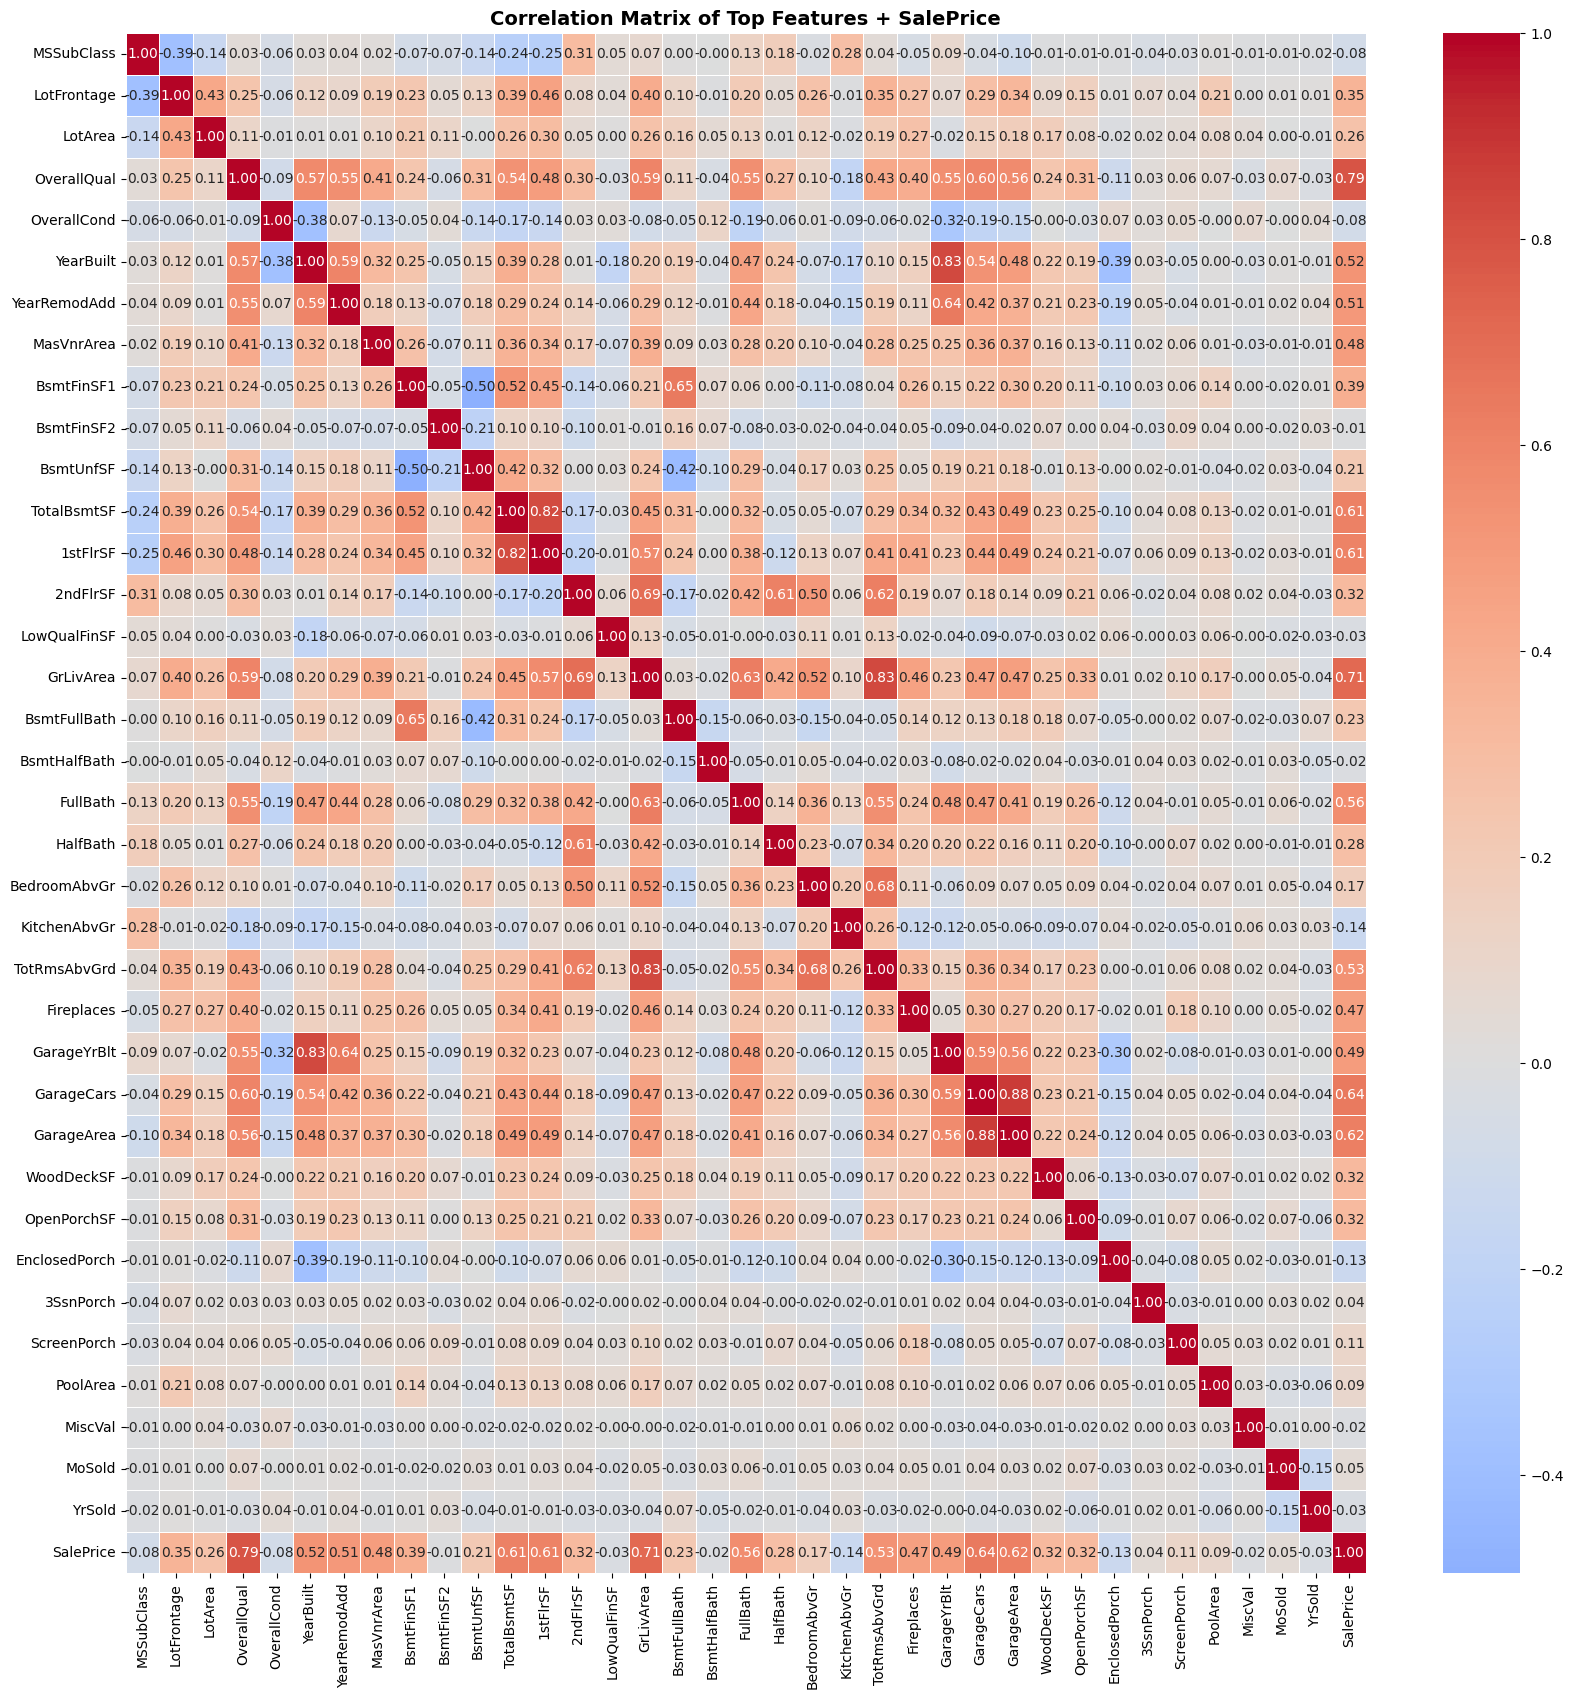

In [1267]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(20, 20))
plt.title('Correlation Matrix of Top Features + SalePrice', fontsize=14, fontweight='bold')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0,
            linewidths=0.5)

plt.show()

In [1268]:
corr_matrix["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

In [1269]:
df.select_dtypes(np.number).isnull().sum().sort_values(ascending=False)

LotFrontage      259
GarageYrBlt       81
MasVnrArea         8
MSSubClass         0
LotArea            0
OverallCond        0
OverallQual        0
YearRemodAdd       0
YearBuilt          0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
BsmtFinSF1         0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
1stFlrSF           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [1270]:
top_numeric_features = ['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'FullBath','1stFlrSF', 'TotRmsAbvGrd','LotArea','GarageCars','MasVnrArea','LotFrontage']
top_cat_features= ['HouseStyle']
print("\nTop 5 features with most missing values:",top_numeric_features)


Top 5 features with most missing values: ['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'FullBath', '1stFlrSF', 'TotRmsAbvGrd', 'LotArea', 'GarageCars', 'MasVnrArea', 'LotFrontage']


In [1271]:
x=df[top_numeric_features+top_cat_features]
y=df["SalePrice"]

x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)
x.head()

,OverallQual,GrLivArea,GarageArea,TotalBsmtSF,FullBath,1stFlrSF,TotRmsAbvGrd,LotArea,GarageCars,MasVnrArea,LotFrontage,HouseStyle
0,7,1710,548,856,2,856,8,8450,2,196.0,65.0,2Story
1,6,1262,460,1262,2,1262,6,9600,2,0.0,80.0,1Story
2,7,1786,608,920,2,920,6,11250,2,162.0,68.0,2Story
3,7,1717,642,756,1,961,7,9550,3,0.0,60.0,2Story
4,8,2198,836,1145,2,1145,9,14260,3,350.0,84.0,2Story


In [1272]:
x_train['MasVnrArea'].isnull().sum()

np.int64(2)

In [1273]:
# r_scaller= RobustScaler()
# x_train[top_numeric_features]= r_scaller.fit_transform(x_train[top_numeric_features])
# x_val[top_numeric_features] = r_scaller.transform(x_val[top_numeric_features])
# x_test[top_numeric_features] =r_scaller.transform(x_test[top_numeric_features])


In [1274]:
x_train.columns

Index(['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF', 'FullBath',
       '1stFlrSF', 'TotRmsAbvGrd', 'LotArea', 'GarageCars', 'MasVnrArea',
       'LotFrontage', 'HouseStyle'],
      dtype='str')

In [1275]:
numeric_zero_cols=['MasVnrArea']
for split in [x_train, x_val, x_test]:
    for col in numeric_zero_cols:
        if col in split.columns:
            split[col] = split[col].fillna(0)
split['MasVnrArea'] = split['MasVnrArea'].fillna(0)
split['MasVnrArea'].sort_values(ascending=False).tail(8)

371     0.0
1085    0.0
374     0.0
247     0.0
711     0.0
1249    0.0
415     0.0
544     0.0
Name: MasVnrArea, dtype: float64

In [1276]:

# med_imp = SimpleImputer(strategy='median')
# x_train[['LotFrontage']] = med_imp.fit_transform(x_train[['LotFrontage']])
# x_val[['LotFrontage']]   = med_imp.transform(x_val[['LotFrontage']])
# x_test[['LotFrontage']]  = med_imp.transform(x_test[['LotFrontage']])

In [1277]:
# oh_encode= OneHotEncoder(handle_unknown='ignore',sparse_output=False)
# x_train_enc = oh_encode.fit_transform(x_train[top_cat_features])
# x_val_enc = oh_encode.transform(x_val[top_cat_features])
# x_test_enc  = oh_encode.transform(x_test[top_cat_features])


In [1278]:

cat_cols = top_cat_features
num_scale_cols = top_numeric_features

cat_pipe = Pipeline([
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# lot_pipe = Pipeline([
  
# ])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe, num_scale_cols)
], remainder='drop')

In [1279]:
x_train.isnull().sum()

OverallQual       0
GrLivArea         0
GarageArea        0
TotalBsmtSF       0
FullBath          0
1stFlrSF          0
TotRmsAbvGrd      0
LotArea           0
GarageCars        0
MasVnrArea        0
LotFrontage     167
HouseStyle        0
dtype: int64

In [1280]:
def evaluate_regression(model_name, y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)
  return {
      'model': model_name,
      'mae': mae,
      'rmse': rmse,
      'r2': r2
  }


In [1281]:

xgb_pipeline= Pipeline([
    ('preprocessor',preprocessor),
    ('model',xgboost.XGBRegressor(
    n_estimators=500,random_state=42,n_jobs=-1))
    
])
xgb_pipeline.fit(x_train,y_train)
xgb_test_pred = xgb_pipeline.predict(x_test)
xgb_metrics= evaluate_regression('xgb',y_test,xgb_test_pred)

print(xgb_metrics)

{'model': 'xgb', 'mae': 19880.5, 'rmse': np.float64(27959.417447436204), 'r2': 0.8401564955711365}


In [1282]:
lr_pipeline= Pipeline([
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
    
])
lr_pipeline.fit(x_train,y_train)
lr_test_pred = lr_pipeline.predict(x_test)
lr_metrics= evaluate_regression('lr',y_test,lr_test_pred)

print(lr_metrics)

{'model': 'lr', 'mae': 23964.433145234238, 'rmse': np.float64(32458.78376808481), 'r2': 0.7845714290566511}


In [1290]:
if xgb_metrics['r2'] >=  lr_metrics['r2']:
    best_model= xgb_pipeline
else:
    best_model= lr_pipeline

joblib.dump(best_model,Path("../model/model_pipeline.joblib"))

['..\\model\\model_pipeline.joblib']

In [1293]:
stats = {
    "median": 160000.0,
    "q1": 120000.0,
    "q3": 210000.0,
    "top_features": ["OverallQual", "GrLivArea", "GarageCars"]
}

joblib.dump(stats, "../model/train_stats.joblib")
print("✅ Created models/train_stats.joblib")

✅ Created models/train_stats.joblib


In [1296]:
features = {
      "OverallQual": 7,
      "GrLivArea": 1800,
      "GarageArea": 800,
      "TotalBsmtSF": 1000,
      "FullBath": 2,
      "1stFlrSF": 1800,
      "TotRmsAbvGrd": 6,
      "LotArea": 10000,
      "GarageCars": 2,
      "MasVnrArea": 0,
      "LotFrontage": 60,
      "HouseStyle": "1Story"
    }
x_test = pd.DataFrame([features])
y_pred = best_model.predict(x_test)
print(y_pred)


[214846.8]
